In [1]:
# Load data set
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

display(df)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [10]:
# Train and test
from sklearn.model_selection import train_test_split

# Selec a few coluns
df = df[[
    'mean texture',
    'mean concave points',
    'worst radius',
    'radius error',
    'worst concavity',
    'target',
]]

df_train, df_val = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["target"]  # mantém proporção da classe
)

display(df_train)

,mean texture,mean concave points,worst radius,radius error,worst concavity,target
469,18.18,0.05564,13.36,0.4101,0.31860,1
561,29.37,0.00000,11.92,0.3141,0.00000,1
443,18.32,0.01111,10.94,0.1818,0.03986,1
362,18.84,0.01781,13.75,0.2213,0.12550,1
271,13.04,0.02755,12.32,0.1904,0.12750,1
...,...,...,...,...,...,...
184,22.41,0.03263,17.80,0.2054,0.36300,0
300,18.90,0.10620,25.93,1.1110,0.61210,0
220,13.16,0.02563,15.34,0.2102,0.17590,1
230,19.08,0.10900,19.59,0.2959,0.50180,0


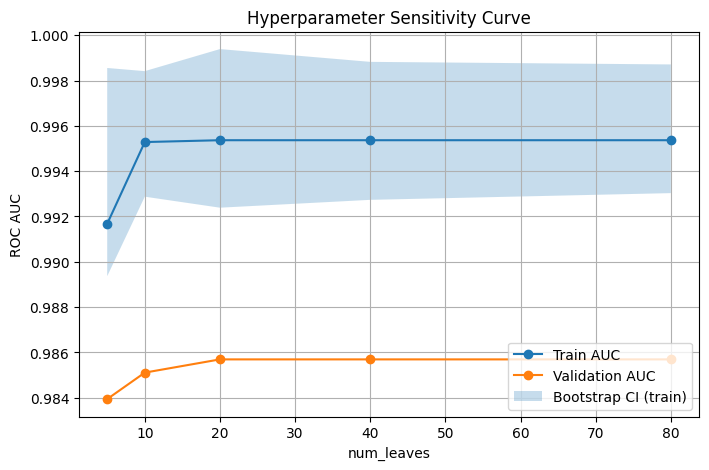

   num_leaves  train_auc   val_auc  bootstrap_mean  ci_lower  ci_upper
0           5   0.991676  0.983937        0.994430  0.989363  0.998554
1          10   0.995284  0.985105        0.996207  0.992872  0.998415
2          20   0.995365  0.985689        0.996074  0.992386  0.999388
3          40   0.995365  0.985689        0.996043  0.992732  0.998824
4          80   0.995365  0.985689        0.996247  0.993029  0.998710

{'objective': 'binary', 'boosting_type': 'gbdt', 'verbosity': -1, 'is_unbalanced': True, 'n_estimators': 10, 'learning_rate': 0.05, 'num_leaves': np.int64(20), 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8}


In [14]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score


def lightgbm_hyperparameter_auc_curve_bootstrap(
    X_train,
    y_train,
    X_val,
    y_val,
    hyperparameters,
    hyperparameter_name,
    hyperparameter_values,
    n_bootstrap=100,
    ci=0.95,
    random_state=42
):
    """
    Hyperparameter sensitivity analysis with bootstrap confidence intervals.

    Bootstrap is applied to the training set.
    Validation set is fixed (out-of-time).
    """

    rng = np.random.default_rng(random_state)

    results = []

    n = len(X_train)

    for value in hyperparameter_values:

        params = hyperparameters.copy()
        params[hyperparameter_name] = value
        params["random_state"] = random_state

        bootstrap_scores = []

        # ----------------------
        # Bootstrap training
        # ----------------------

        for _ in range(n_bootstrap):

            idx = rng.integers(0, n, n)

            X_boot = X_train.iloc[idx]
            y_boot = y_train.iloc[idx]

            model = lgb.LGBMClassifier(**params)

            model.fit(X_boot, y_boot)

            pred = model.predict_proba(X_boot)[:, 1]

            auc = roc_auc_score(y_boot, pred)

            bootstrap_scores.append(auc)

        bootstrap_scores = np.array(bootstrap_scores)

        alpha = (1 - ci) / 2

        ci_lower = np.quantile(bootstrap_scores, alpha)
        ci_upper = np.quantile(bootstrap_scores, 1 - alpha)

        # ----------------------
        # Train final model
        # ----------------------

        model = lgb.LGBMClassifier(**params)

        model.fit(X_train, y_train)

        train_pred = model.predict_proba(X_train)[:, 1]
        val_pred = model.predict_proba(X_val)[:, 1]

        train_auc = roc_auc_score(y_train, train_pred)
        val_auc = roc_auc_score(y_val, val_pred)

        results.append({
            hyperparameter_name: value,
            "train_auc": train_auc,
            "val_auc": val_auc,
            "bootstrap_mean": bootstrap_scores.mean(),
            "ci_lower": ci_lower,
            "ci_upper": ci_upper
        })

    df_results = pd.DataFrame(results)

    # ----------------------------------
    # Select best hyperparameter value
    # ----------------------------------
    
    best_idx = df_results["val_auc"].idxmax()
    best_value = df_results.loc[best_idx, hyperparameter_name]
    
    best_hyperparameters = hyperparameters.copy()
    best_hyperparameters[hyperparameter_name] = best_value

    # ----------------------
    # Plot
    # ----------------------

    x = df_results[hyperparameter_name]

    plt.figure(figsize=(8, 5))

    plt.plot(x, df_results["train_auc"], marker="o", label="Train AUC")
    plt.plot(x, df_results["val_auc"], marker="o", label="Validation AUC")

    plt.fill_between(
        x,
        df_results["ci_lower"],
        df_results["ci_upper"],
        alpha=0.25,
        label="Bootstrap CI (train)"
    )

    plt.xlabel(hyperparameter_name)
    plt.ylabel("ROC AUC")

    plt.title("Hyperparameter Sensitivity Curve")

    plt.grid(True)
    plt.legend()

    plt.show()

    return {
        "results": df_results,
        "best_hyperparameters": best_hyperparameters
    }

# Example usage
# -----------------------------
# Separate features and target
# -----------------------------
X_train = df_train.drop(columns=["target"])
y_train = df_train["target"]

X_val = df_val.drop(columns=["target"])
y_val = df_val["target"]

# -----------------------------
# Base hyperparameters
# -----------------------------
hyperparameters = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "verbosity": -1,
    "is_unbalanced": True,
    "n_estimators": 10,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

# -----------------------------
# Run hyperparameter analysis
# -----------------------------
analysis = lightgbm_hyperparameter_auc_curve_bootstrap(
    X_train,
    y_train,
    X_val,
    y_val,
    hyperparameters=hyperparameters,
    hyperparameter_name="num_leaves",
    hyperparameter_values=[5,10,20,40,80],
    n_bootstrap=200
)

print(analysis["results"])
print()
print(analysis["best_hyperparameters"])

hyperparameters = analysis["best_hyperparameters"]